# Olympic Odysseys: The Impact of the "Golden Goal" On The Price Of Hockey Cards

Jude Yurcich
ECO 590
Spring 2026

# This notebook contains an eBay API, cleaning that API, as well as graphs

# Motivation

One of the most famous speculative markets outside of formalized market trading is the sports card market, and for good reason. Sports cards come in all sorts of variations and can sell for millions of dollars, demonstrating how much money is in the market. For example, a joint Kobe Bryant and Michael Jordan basketball card sold for $12.9 million in August of 2025. eBay is one of the most important platforms to buy not only trading cards, but almost anything that has value. The 2026 Winter Olympics in Milano Cortina featured an ice hockey tournament among major hockey nations, with the United States beating Canada in overtime of the final. The scorer of the "Golden Goal," Jack Hughes, is an NHL star and has many cards to his name. I am interested in seeing if the price of his cards went up after the Olympic goal that brought him even more fame. 
https://www.paulfrasercollectibles.com/blogs/most-recent/the-most-valuable-sports-trading-cards-of-all-time?srsltid=AfmBOooGrkM4DR18Z55j1RqqhnHuIAuRLrZQIpkfzT3h61T9kjnHd6A9

# Research Question

1. Did the 2026 Winter Olympics results cause Jack Hughes' graded hockey cards to rise in value?

# Part 1: eBay API

In [1]:
#This will import the packages that I need to do data analysis
import requests
import re
import ast
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#imports api from provider
from serpapi import EbaySearch

#These are the parameters for the API search
params = {
    "engine": "ebay",
    "_nkw": "jack hughes young guns psa 10",
    "ebay_domain": "ebay.com",
    "api_key": "12a13973b8d58a4cc7b569859b257ef029573e1b3f116a9ecfcebd95b1f016a5",
    "show_only": "Sold",
    "buying_format": "BIN",
    "lh_sold": "1",
    "_ipg": "200"
}

# This code will search within the parameters and create a variable for the results
search = EbaySearch(params)
results = search.get_dict()

# This creates a json for the results so it can be turned into a dataframe
data_json = json.dumps(results)

# This will turn the json into a dataframe
df1 = pd.DataFrame(results["organic_results"])
df1.to_csv("df1_output.csv", index=False)

In [2]:
# Creates "expensive" variable for cards worth more than 300 dollars
expensive = [
    item for item in results["organic_results"]
    if isinstance(item.get("price"), dict)
    and item["price"].get("extracted", 0) > 300
    and item.get("sold_date") is not None
]
# This will turn the json into a dataframe
dfE = pd.DataFrame(expensive)

# Part 2: Cleaning the Data

In [3]:
# Prints part of dataframe to see what it looks like
df1

,title,link,serpapi_link,product_id,condition,price,shipping,location,returns,buying_format,buying_format_text,thumbnail,seller,sold_date,epid,rating,reviews,extensions,old_price,subtitle
0,2019-20 Series 1 - Jack Hughes Rookie RC YOUNG...,https://www.ebay.com/itm/389860032154?_skw=jac...,https://serpapi.com/search.json?ebay_domain=eb...,389860032154,New (Other),"{'raw': '$204.69', 'extracted': 204.69}","{'raw': '+$13.75 delivery', 'extracted': 13.75}",Located in Canada,Sell one like this,buy_it_now,Buy It Now,https://i.ebayimg.com/images/g/hQcAAeSwmIZp1ZP...,"{'username': 'monkeymansports', 'reviews': 110...","May 5, 2026",NaN,NaN,NaN,NaN,NaN,NaN
1,2019 Jack Hughes O-Pee-Chee OPC Update Retro M...,https://www.ebay.com/itm/137288306534?_skw=jac...,https://serpapi.com/search.json?ebay_domain=eb...,137288306534,New (Other),"{'raw': '$150.00', 'extracted': 150.0}","{'raw': '+$5.72 delivery', 'extracted': 5.72}",Located in United States,Sell one like this,accepts_offers,or Best Offer,https://i.ebayimg.com/images/g/nrsAAeSw16pp-95...,"{'username': 'avcards16', 'reviews': 20, 'posi...","May 9, 2026",9056541523,NaN,NaN,NaN,NaN,NaN
2,2019 Upper Deck Quinn Hughes Young Guns PSA 10,https://www.ebay.com/itm/157897248275?_skw=jac...,https://serpapi.com/search.json?ebay_domain=eb...,157897248275,New (Other),"{'raw': '$275.00', 'extracted': 275.0}","{'raw': '+$6.00 delivery', 'extracted': 6.0}",Located in United States,Sell one like this,accepts_offers,or Best Offer,https://i.ebayimg.com/images/g/c3AAAeSw7pFp~1~...,"{'username': 'braydesega_0', 'reviews': 511, '...","May 9, 2026",21056483551,5.0,1.0,[Authenticity Guarantee],NaN,NaN
3,2019-20 Upper Deck - Young Guns Jack Hughes #2...,https://www.ebay.com/itm/318244628865?_skw=jac...,https://serpapi.com/search.json?ebay_domain=eb...,318244628865,New (Other),"{'raw': '$130.00', 'extracted': 130.0}","{'raw': '+$5.17 delivery', 'extracted': 5.17}",Located in United States,Sell one like this,accepts_offers,or Best Offer,https://i.ebayimg.com/images/g/rZcAAeSwTpVp99k...,"{'username': 'aasche43', 'reviews': 5, 'positi...","May 8, 2026",8056494284,5.0,5.0,NaN,NaN,NaN
4,2024 Upper Deck Jack Hughes Young Guns Renewed...,https://www.ebay.com/itm/127853238112?_skw=jac...,https://serpapi.com/search.json?ebay_domain=eb...,127853238112,New (Other),"{'raw': '$110.00', 'extracted': 110.0}","{'raw': '+$5.62 delivery', 'extracted': 5.62}",Located in United States,Sell one like this,accepts_offers,or Best Offer,https://i.ebayimg.com/images/g/pDsAAeSwhIJp~Z2...,"{'username': 'tokyoprizmcollections', 'reviews...","May 8, 2026",4077830022,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,2019-20 UD Shooting Stars Jack Hughes ROOKIE #...,https://www.ebay.com/itm/404322038011?_skw=jac...,https://serpapi.com/search.json?ebay_domain=eb...,404322038011,New (Other),"{'raw': '$75.00', 'extracted': 75.0}","{'raw': '+$5.00 delivery', 'extracted': 5.0}",Located in United States,Sell one like this,accepts_offers,or Best Offer,https://i.ebayimg.com/images/g/4AYAAOSwLSpkf1N...,"{'username': 'wingsunion', 'reviews': 1100, 'p...","Feb 26, 2026",11089766272,NaN,NaN,NaN,NaN,NaN
236,JACK HUGHES 2019-20 Upper Deck Young Guns RC #...,https://www.ebay.com/itm/277747402089?_skw=jac...,https://serpapi.com/search.json?ebay_domain=eb...,277747402089,New (Other),"{'raw': '$299.99', 'extracted': 299.99}","{'raw': '+$8.99 delivery', 'extracted': 8.99}",Located in United States,Sell one like this,buy_it_now,Buy It Now,https://i.ebayimg.com/images/g/0a8AAeSwmDRpm2v...,"{'username': 'curly0597', 'reviews': 2700, 'po...","Feb 26, 2026",8056494284,5.0,5.0,[Authenticity Guarantee],NaN,NaN
237,2019-20 Upper Deck Jack Hughes Young Guns Rook...,https://www.ebay.com/itm/236657453349?_skw=jac...,https://serpapi.com/search.json?ebay_domain=eb...,236657453349,New (Other),"{'raw': '$318.60', 'extracted': 318.6}","{'raw': '+$6.00 delivery', 'extracted': 6.0}",Located in United States,Sell one like t

In [4]:
# Prints part of the dataframe to see what it looks like
dfE

,title,link,serpapi_link,product_id,epid,condition,rating,reviews,price,old_price,shipping,location,returns,buying_format,buying_format_text,thumbnail,seller,sold_date,extensions,subtitle
0,Jack Hughes Signed 2019/20 Upper Deck Young Gu...,https://www.ebay.com/itm/166300395404?_skw=jac...,https://serpapi.com/search.json?ebay_domain=eb...,166300395404,8056494284,Pre-Owned,5.0,5.0,"{'raw': '$799.99', 'extracted': 799.99}","{'raw': '$999.99', 'extracted': 999.99, 'disco...","{'raw': '+$5.89 delivery', 'extracted': 5.89}",Located in United States,Sell one like this,accepts_offers,or Best Offer,https://i.ebayimg.com/images/g/sHgAAOSw4epk6pB...,"{'username': 'filaman_2700', 'reviews': 2100, ...","May 5, 2026",NaN,NaN
1,2019-20 Upper Deck - Young Guns Jack Hughes #2...,https://www.ebay.com/itm/137270375762?_skw=jac...,https://serpapi.com/search.json?ebay_domain=eb...,137270375762,8056494284,New (Other),5.0,5.0,"{'raw': '$349.99', 'extracted': 349.99}",NaN,"{'raw': '+$5.72 delivery', 'extracted': 5.72}",Located in United States,Sell one like this,accepts_offers,or Best Offer,https://i.ebayimg.com/images/g/Jv8AAeSwQOlp8-M...,"{'username': 'concerdanman', 'reviews': 2800, ...","May 4, 2026",[Authenticity Guarantee],NaN
2,2019 Upper Deck #250 Jack Hughes & Quinn Hughe...,https://www.ebay.com/itm/266951642862?_skw=jac...,https://serpapi.com/search.json?ebay_domain=eb...,266951642862,25056561784,New (Other),NaN,NaN,"{'raw': '$2,800.00', 'extracted': 2800.0}","{'raw': '$4,000.00', 'extracted': 4000.0, 'dis...","{'raw': '+$6.50 delivery', 'extracted': 6.5}",Located in United States,Sell one like this,accepts_offers,or Best Offer,https://i.ebayimg.com/images/g/JIgAAOSwksdmvqq...,"{'username': 'cf12enterprises', 'reviews': 480...","May 3, 2026",[Authenticity Guarantee],NaN
3,CONNOR MCDAVID 2015-16 Upper Deck Young Guns U...,https://www.ebay.com/itm/318174235523?_skw=jac...,https://serpapi.com/search.json?ebay_domain=eb...,318174235523,NaN,New (Other),NaN,NaN,"{'raw': '$1,645.09', 'extracted': 1645.09}",NaN,"{'raw': '+$56.96 delivery', 'extracted': 56.96}",Located in Canada,Sell one like this,accepts_offers,or Best Offer,https://i.ebayimg.com/images/g/tzgAAeSwFCdp5WU...,"{'username': 'ig_tmcards', 'reviews': 1100, 'p...","Apr 23, 2026",NaN,NaN
4,2019-20 Upper Deck - Young Guns Jack Hughes #2...,https://www.ebay.com/itm/336523806022?_skw=jac...,https://serpapi.com/search.json?ebay_domain=eb...,336523806022,3056541229,New (Other),NaN,NaN,"{'raw': '$525.00', 'extracted': 525.0}",NaN,"{'raw': '+$8.95 delivery', 'extracted': 8.95}",Located in United States,Sell one like this,buy_it_now,Buy It Now,https://i.ebayimg.com/images/g/fOsAAeSwi45p1b9...,"{'username': 'meyekal', 'reviews': 158, 'posit...","Apr 24, 2026",[Authenticity Guarantee],NaN
5,2019-20 Upper Deck JACK HUGHES YOUNG GUNS ROOK...,https://www.ebay.com/itm/366301188279?_skw=jac...,https://serpapi.com/search.json?ebay_domain=eb...,366301188279,3056541229,New (Other),NaN,NaN,"{'raw': '$750.00', 'extracted': 750.0}",NaN,"{'raw': '+$5.97 delivery', 'extracted': 5.97}",Located in United States,Sell one like this,accepts_offers,or Best Offer,https://i.ebayimg.com/images/g/hfsAAeSwb5xpwxb...,"{'username': 'getitlike123', 'reviews': 602, '...","Mar 28, 2026",[Authenticity Guarantee],NaN
6,2019-20 Upper Deck Jack Hughes #201 Clear Cut ...,https://www.ebay.com/itm/157739834785?_skw=jac...,https://serpapi.com/search.json?ebay_domain=eb...,157739834785,17056478034,New (Other),NaN,NaN,"{'raw': '$1,199.86', 'extracted': 1199.86}",NaN,Free delivery,Located in United States,Sell one like this,buy_it_now,Buy It Now,https://i.ebayimg.com/images/g/~jsAAeSwPN5p4Ud...,"{'username': 'tmhunh', 'reviews': 14300, 'posi...","Apr 23, 2026",[Authenticity Guarantee],NaN
7,2019-20 Upper Deck Quinn Hughes Young Guns Roo...,https://www.ebay.com/itm/236655628083?_skw=jac...,https://serpapi.com/search.json?ebay_domain=eb...,236655628083,21056483551,New (Other),5.0,1.0,"{'raw': '$319.99', 'extracted': 319.99}",NaN,"{'raw': '

Obviously, this is still quite unclean, so we must fix this.

# Cleaning Some Variables

In [5]:
# ONLY RUN THIS ONCE PER API USAGE (extracts PRICE and SHIPPING with TITLE from the unclean data)
df1['price'] = df1['price'].apply(lambda x: x.get('extracted') if isinstance(x, dict) else None)
df1['shipping'] = df1['shipping'].apply(lambda x: x.get('extracted') if isinstance(x, dict) else 0)
df1['old_price'] = df1['old_price'].apply(lambda x: x.get('extracted') if isinstance(x, dict) else None)

# Prints a few lines to ensure the cleaning was done correctly 
print(df1[['title', 'price', 'shipping']].head())
df1.to_csv("df1_output.csv", index=False)

# ONLY RUN THIS ONCE PER API USAGE (extracts PRICE and SHIPPING with TITLE from the unclean data)
dfE['price'] = dfE['price'].apply(lambda x: x.get('extracted') if isinstance(x, dict) else None)
dfE['shipping'] = dfE['shipping'].apply(lambda x: x.get('extracted') if isinstance(x, dict) else 0)
dfE['old_price'] = dfE['old_price'].apply(lambda x: x.get('extracted') if isinstance(x, dict) else None)

# Prints a few lines to ensure the cleaning was done correctly 
print(dfE[['title', 'price', 'shipping']].head())
dfE.to_csv("dfE_output.csv", index=False)

                                               title   price  shipping
0  2019-20 Series 1 - Jack Hughes Rookie RC YOUNG...  204.69     13.75
1  2019 Jack Hughes O-Pee-Chee OPC Update Retro M...  150.00      5.72
2     2019 Upper Deck Quinn Hughes Young Guns PSA 10  275.00      6.00
3  2019-20 Upper Deck - Young Guns Jack Hughes #2...  130.00      5.17
4  2024 Upper Deck Jack Hughes Young Guns Renewed...  110.00      5.62
                                               title    price  shipping
0  Jack Hughes Signed 2019/20 Upper Deck Young Gu...   799.99      5.89
1  2019-20 Upper Deck - Young Guns Jack Hughes #2...   349.99      5.72
2  2019 Upper Deck #250 Jack Hughes & Quinn Hughe...  2800.00      6.50
3  CONNOR MCDAVID 2015-16 Upper Deck Young Guns U...  1645.09     56.96
4  2019-20 Upper Deck - Young Guns Jack Hughes #2...   525.00      8.95


In [6]:
# Reads csv
df1 = pd.read_csv("df1_output.csv")

# Convert sold_date to datetime
df1['sold_date'] = pd.to_datetime(df1['sold_date'], format='mixed')

# Create dummy for sales after Feb 22 2026
df1['after_feb22'] = df1['sold_date'].apply(lambda x: 1 if x > pd.Timestamp('2026-02-22') else 0)

# Prints out first few lines of csv to ensure cleaning was done correctly
print(df1[['title', 'price', 'sold_date', 'after_feb22']].head())

#Saves to csv
df1.to_csv("df1_output.csv", index=False)


                                               title   price  sold_date  \
0  2019-20 Series 1 - Jack Hughes Rookie RC YOUNG...  204.69 2026-05-05   
1  2019 Jack Hughes O-Pee-Chee OPC Update Retro M...  150.00 2026-05-09   
2     2019 Upper Deck Quinn Hughes Young Guns PSA 10  275.00 2026-05-09   
3  2019-20 Upper Deck - Young Guns Jack Hughes #2...  130.00 2026-05-08   
4  2024 Upper Deck Jack Hughes Young Guns Renewed...  110.00 2026-05-08   

   after_feb22  
0            1  
1            1  
2            1  
3            1  
4            1  


In [7]:
# Reads csv
df1 = pd.read_csv("df1_output.csv")

# Eliminates ratings that do not exist
df1['rating'] = df1['rating'].fillna('')
df1.to_csv("df1_output.csv", index=False)

# Prints few lines of csv to ensure cleaning was done correctly
print(df1['rating'].head(10))

0       
1       
2    5.0
3    5.0
4       
5       
6       
7       
8    5.0
9    5.0
Name: rating, dtype: object


In [8]:
# Reads csv
dfE = pd.read_csv("dfE_output.csv")

# Eliminates ratings that do not exist
dfE['rating'] = dfE['rating'].fillna('')
dfE.to_csv("dfE_output.csv", index=False)

# Prints few lines of csv to ensure that cleaning was done correctly
print(dfE['rating'].head(10))

0    5.0
1    5.0
2       
3       
4       
5       
6       
7    5.0
8       
9       
Name: rating, dtype: object


In [9]:
# Drops unneeded columns
df1 = df1.drop(columns=['link', 'serpapi_link', 'product_id', 'returns', 'buying_format', 'buying_format_text', 'thumbnail', 'seller', 'extensions', 'epid', 'reviews', 'old_price', 'subtitle'])

In [10]:
# 1 = Located in United States, 0 = everywhere else
df1['us_seller'] = (df1['location'] == 'Located in United States').astype(int)

In [11]:
# Logs price and shipping for future regressions
df1['Log of Price'] = np.log(df1['price'])
df1['Log of Shipping'] = np.log(df1['shipping'] + 1)  # +1 to handle free shipping

In [12]:
# Renames columns
df1.columns = ['Title', 'Condition', 'Price', 'Shipping', 'Location', 'Sold Date', 'Rating', 'Sold After 2/22/26', 'US Seller', 'Log of Price', 'Log of Shipping',]  # must match total number of columns

In [13]:
# Prints dataframe
df1

,Title,Condition,Price,Shipping,Location,Sold Date,Rating,Sold After 2/22/26,US Seller,Log of Price,Log of Shipping
0,2019-20 Series 1 - Jack Hughes Rookie RC YOUNG...,New (Other),204.69,13.75,Located in Canada,2026-05-05,,1,0,5.321497,2.691243
1,2019 Jack Hughes O-Pee-Chee OPC Update Retro M...,New (Other),150.00,5.72,Located in United States,2026-05-09,,1,1,5.010635,1.905088
2,2019 Upper Deck Quinn Hughes Young Guns PSA 10,New (Other),275.00,6.00,Located in United States,2026-05-09,5.0,1,1,5.616771,1.945910
3,2019-20 Upper Deck - Young Guns Jack Hughes #2...,New (Other),130.00,5.17,Located in United States,2026-05-08,5.0,1,1,4.867534,1.819699
4,2024 Upper Deck Jack Hughes Young Guns Renewed...,New (Other),110.00,5.62,Located in United States,2026-05-08,,1,1,4.700480,1.890095
...,...,...,...,...,...,...,...,...,...,...,...
235,2019-20 UD Shooting Stars Jack Hughes ROOKIE #...,New (Other),75.00,5.00,Located in United States,2026-02-26,,1,1,4.317488,1.791759
236,JACK HUGHES 2019-20 Upper Deck Young Guns RC #...,New (Other),299.99,8.99,Located in United States,2026-02-26,5.0,1,1,5.703749,2.301585
237,2019-20 Upper Deck Jack Hughes Young Guns Rook...,New (Other),318.60,6.00,Located in United States,2026-02-26,5.0,1,1,5.763936,1.945910
238,2019-20 Upper Deck - Young Guns Jack Hughes #2...,New (Other),315.00,0.00,Located in United States,2026-02-26,5.0,1,1,5.752573,0.000000


In [14]:
# Drops unneeded columns
dfE = dfE.drop(columns=['link', 'serpapi_link', 'product_id', 'returns', 'buying_format', 'buying_format_text', 'thumbnail', 'seller', 'extensions', 'epid', 'reviews', 'old_price', 'subtitle'])

In [15]:
# 1 = Located in United States, 0 = everywhere else
dfE['us_seller'] = (dfE['location'] == 'Located in United States').astype(int)

In [16]:
#Logs price and shipping for future regressions
dfE['log_price'] = np.log(dfE['price'])
dfE['Log of Shipping'] = np.log(dfE['shipping'] + 1)  # +1 to handle free shipping

In [17]:
# Renames columns
dfE.columns = ['Title', 'Condition', 'Rating', 'Price', 'Shipping', 'Location', 'Sold Date', 'US Seller', 'Log of Price', 'Log of Shipping']  # must match total number of columns

In [18]:
#Prints dataframe
dfE

,Title,Condition,Rating,Price,Shipping,Location,Sold Date,US Seller,Log of Price,Log of Shipping
0,Jack Hughes Signed 2019/20 Upper Deck Young Gu...,Pre-Owned,5.0,799.99,5.89,Located in United States,"May 5, 2026",1,6.684599,1.930071
1,2019-20 Upper Deck - Young Guns Jack Hughes #2...,New (Other),5.0,349.99,5.72,Located in United States,"May 4, 2026",1,5.857905,1.905088
2,2019 Upper Deck #250 Jack Hughes & Quinn Hughe...,New (Other),,2800.00,6.50,Located in United States,"May 3, 2026",1,7.937375,2.014903
3,CONNOR MCDAVID 2015-16 Upper Deck Young Guns U...,New (Other),,1645.09,56.96,Located in Canada,"Apr 23, 2026",0,7.405550,4.059753
4,2019-20 Upper Deck - Young Guns Jack Hughes #2...,New (Other),,525.00,8.95,Located in United States,"Apr 24, 2026",1,6.263398,2.297573
5,2019-20 Upper Deck JACK HUGHES YOUNG GUNS ROOK...,New (Other),,750.00,5.97,Located in United States,"Mar 28, 2026",1,6.620073,1.941615
6,2019-20 Upper Deck Jack Hughes #201 Clear Cut ...,New (Other),,1199.86,0.00,Located in United States,"Apr 23, 2026",1,7.089960,0.000000
7,2019-20 Upper Deck Quinn Hughes Young Guns Roo...,New (Other),5.0,319.99,6.00,Located in United States,"Apr 22, 2026",1,5.768290,1.945910
8,2019-20 Upper Deck Speckled Rainbow Foil Jack ...,New (Other),,428.00,4.99,Located in United States,"Apr 19, 2026",1,6.059123,1.790091
9,2019-20 Jack Hughes UD Young Guns Speckled Rai...,New (Other),,1999.00,5.97,Located in United States,"Apr 18, 2026",1,7.600402,1.941615


In [19]:
# Saves csvs

df1.to_csv("df1_output.csv", index=False)
dfE.to_csv("dfE_output.csv", index=False)

### Interestingly enough, all of the most expensive cards were scored after the "Golden Goal." The data looks quite clean now and ready for analysis.

# Part 3: Graphs

## Graphs: Price vs. Shipping and Price Histogram

This may not seem very interesting at first, but I want to figure out if higher prices for cards lead to higher shipping as an exercise in behavioral economics. If something is so expensive and one adds an extra fee on top of everything, will that really impact the willingness of a person to buy that product? I also want to see the distribution of how many cards were sold for at what prices.

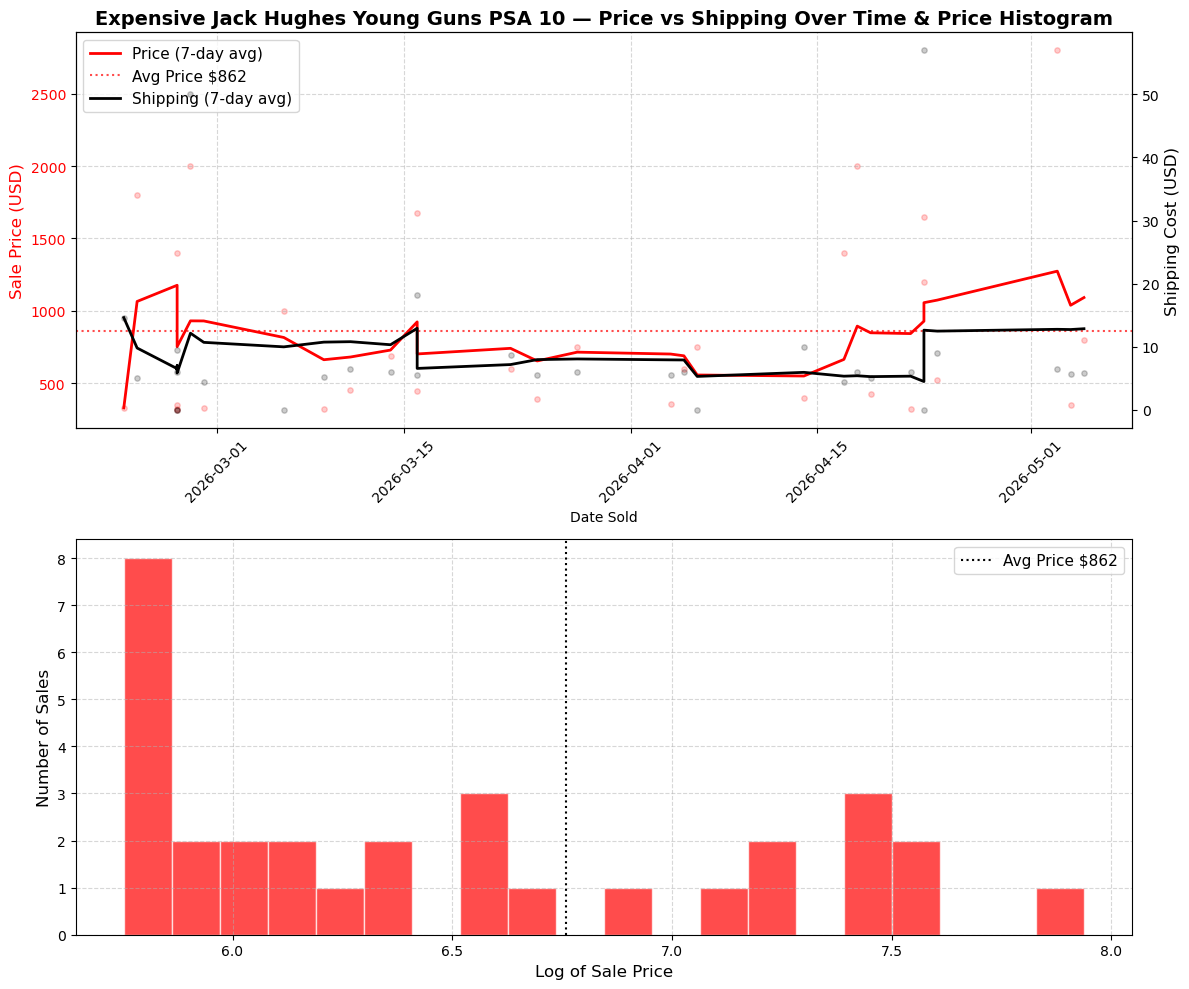

In [20]:
# Load csv
dfE = pd.read_csv("dfE_output.csv")
dfE['Sold Date'] = pd.to_datetime(dfE['Sold Date'], format='mixed')
dfE_sorted = dfE.sort_values('Sold Date').reset_index(drop=True)

# Roling averages
dfE_sorted['price_rolling'] = dfE_sorted['Price'].rolling(window=7, min_periods=1).mean()
dfE_sorted['shipping_rolling'] = dfE_sorted['Shipping'].rolling(window=7, min_periods=1).mean()

# Calculates mean
avg_price = dfE_sorted['Price'].mean()

# Creates figure
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(12, 10))

# Price on left axis
ax1.plot(dfE_sorted['Sold Date'], dfE_sorted['price_rolling'],
         color='r', linewidth=2, label='Price (7-day avg)')
ax1.scatter(dfE_sorted['Sold Date'], dfE_sorted['Price'],
            color='r', alpha=0.2, s=15)
ax1.axhline(avg_price, color='r', linestyle=':', linewidth=1.5,
            alpha=0.7, label=f'Avg Price ${avg_price:.0f}')
ax1.set_xlabel('Date Sold')
ax1.set_ylabel('Sale Price (USD)', color='r', fontsize=12)
ax1.tick_params(axis='y', labelcolor='r')

# Shipping on right axis
ax2 = ax1.twinx()
ax2.plot(dfE_sorted['Sold Date'], dfE_sorted['shipping_rolling'],
         color='k', linewidth=2, label='Shipping (7-day avg)')
ax2.scatter(dfE_sorted['Sold Date'], dfE_sorted['Shipping'],
            color='k', alpha=0.2, s=15)
ax2.set_ylabel('Shipping Cost (USD)', color='k', fontsize=12)
ax2.tick_params(axis='y', labelcolor='k')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11)

ax1.set_title('Expensive Jack Hughes Young Guns PSA 10 — Price vs Shipping Over Time & Price Histogram', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.tick_params(axis='x', rotation=45)

# Histogram
# Log transform the price
ax3.hist(np.log(dfE_sorted['Price']), bins=20, color='r', edgecolor='white', alpha=0.7)
ax3.axvline(np.log(avg_price), color='k', linestyle=':', linewidth=1.5,
            label=f'Avg Price ${avg_price:.0f}')
ax3.set_xlabel('Log of Sale Price', fontsize=12)
ax3.set_ylabel('Number of Sales', fontsize=12)
ax3.legend(fontsize=11)
ax3.grid(True, linestyle='--', alpha=0.5)

# Creates output
plt.tight_layout()
plt.savefig('Graphs.jpg', dpi=300, bbox_inches='tight')
plt.show()

Now that we have extracted the data, cleaned the data, and visualized it, it is time to run regressions with it.